Step 1: Advanced Data Partitioning (80/10/10 Split)

In this step, we implement a three-way split to ensure a rigorous evaluation:

Test Set (10%): We set aside 10% of the data immediately. This data remains "untouched" and is only used at the very end to report final performance.

Training Set (80%): Used to teach the KNN algorithm the patterns in the car data.

Validation Set (10%): Used for Parameter Tuning (adjusting K). 

We use this set to find the best K value without "spoiling" our final test data.

In [1]:
import pandas as pd
from sklearn.model_selection import train_test_split

# 1. Load the data
columns = ['price', 'maintenance', 'doors', 'seats', 'storage', 'safety', 'shouldBuy']
df = pd.read_csv('data/car.csv', header=0)

# 2. Ordinal Encoding
mapping = {
    'low': 1, 'med': 2, 'high': 3, 'vhigh': 4,
    '2': 2, '3': 3, '4': 4, '5more': 5, 'more': 6,
    'small': 1, 'big': 3
}
for col in columns[:-1]:
    df[col] = df[col].replace(mapping)

# 3. Features and Target
X = df.drop('shouldBuy', axis=1)
y = df['shouldBuy']

# 4. The 3-Way Split Logic
# First, pull out the 10% Test Set
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.10, random_state=42)

# Now, split the remaining 90% into Training (80% of total) and Validation (10% of total)
# 0.111 is roughly 1/9, which turns 90% into 80/10
X_train, X_val, y_train, y_val = train_test_split(X_temp, y_temp, test_size=0.111, random_state=42)

print(f"Training set: {len(X_train)} samples")
print(f"Validation set: {len(X_val)} samples")
print(f"Testing set: {len(X_test)} samples")

Training set: 1382 samples
Validation set: 173 samples
Testing set: 173 samples


C:\Users\binzi\AppData\Local\Temp\ipykernel_18552\2897689265.py:15: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df[col] = df[col].replace(mapping)


Step 2: Model Tuning with Validation Data

We use the Validation Set to test different values for K (n_neighbors). This allows us to see which parameter performs best before we run the model on our final, untouched Test Set. 

In [2]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score

# Tuning: Testing different K values on the Validation Set
k_choices = [3, 5, 7, 9, 11]
best_k = 5
highest_val_score = 0

for k in k_choices:
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    val_score = knn.score(X_val, y_val)
    print(f"K={k} Validation Accuracy: {val_score:.4f}")
    
    if val_score > highest_val_score:
        highest_val_score = val_score
        best_k = k

print(f"\nRecommended K based on Validation: {best_k}")

K=3 Validation Accuracy: 0.8844
K=5 Validation Accuracy: 0.9133
K=7 Validation Accuracy: 0.9133
K=9 Validation Accuracy: 0.8960
K=11 Validation Accuracy: 0.8902

Recommended K based on Validation: 5


Step 3: Final Evaluation (The "Untouched" Test)

Now that we have selected our best K value, we run the model one final time and evaluate it against the Test Set. We will generate a Confusion Matrix and a Classification Report (showing Recall and Accuracy) as requested.

Matplotlib is building the font cache; this may take a moment.


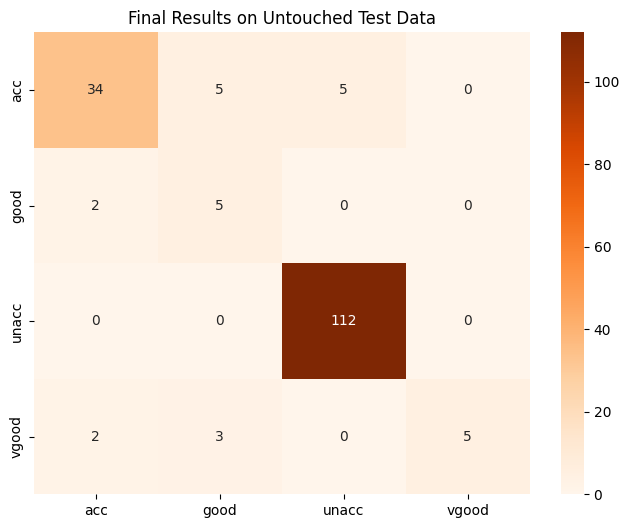

Final Test Accuracy: 90.17%
              precision    recall  f1-score   support

         acc       0.89      0.77      0.83        44
        good       0.38      0.71      0.50         7
       unacc       0.96      1.00      0.98       112
       vgood       1.00      0.50      0.67        10

    accuracy                           0.90       173
   macro avg       0.81      0.75      0.74       173
weighted avg       0.92      0.90      0.90       173



In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix

# Final Model using the best K found above
final_knn = KNeighborsClassifier(n_neighbors=best_k)
final_knn.fit(X_train, y_train)

# Final Prediction on the 10% untouched Test Set
final_preds = final_knn.predict(X_test)

# Visualization
cm = confusion_matrix(y_test, final_preds)
plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges', 
            xticklabels=final_knn.classes_, yticklabels=final_knn.classes_)
plt.title('Final Results on Untouched Test Data')
plt.show()

print(f"Final Test Accuracy: {accuracy_score(y_test, final_preds) * 100:.2f}%")
print(classification_report(y_test, final_preds))